In [7]:
import numpy as np

In [8]:
nx, ny = 4, 2
n = nx * ny

delta = 1.
lamb = 0.
U = 1e4

In [9]:
from lattice_s32 import SpinConfiguration

sc = SpinConfiguration(nx, ny, int(3/2 * n), delta = delta, lamb = lamb, lowest_eignstates=10, print_data=True)
sc.generate_hamiltonian(U = U)
sc.get_eigva_eigve(10)

sum_32 = 0

rot_map = sc.rotation_map

print(r'$S^z_{tot} = 0$')

for repr, basis in sc.representatives.items():
    if sc.map_int_to_config(repr).__contains__(3) or sc.map_int_to_config(repr).__contains__(0):
        contr = np.square(sc.gs_in_basis[basis])
        cfg = sc.map_int_to_config(repr)
        eval = np.mean((cfg - 1) * (cfg - 2))
        #print()
        #print(f'Contribution in the ground state: {round(10e10*contr, 5)}1e-10')
        #print(cfg)
        #print(fr'Eval $\mu$: {round(eval, 5)}')
        sum_32 += contr * eval

sum_32 = U * np.sqrt(sum_32)

sc = SpinConfiguration(nx, ny, int(3/2 * n) + 1, delta = delta, lamb = lamb, lowest_eignstates=10, print_data = True)
sc.generate_hamiltonian(U = U)
sc.get_eigva_eigve(10)

sum_32_1 = 0

rot_map = sc.rotation_map

print(r'$S^z_{tot} = 1$')

for repr, basis in sc.representatives.items():
    if sc.map_int_to_config(repr).__contains__(3) or sc.map_int_to_config(repr).__contains__(0):
        contr = np.square(sc.gs_in_basis[basis])
        cfg = sc.map_int_to_config(repr)
        eval = np.mean((cfg - 1) * (cfg - 2))
        sum_32_1 += contr * eval

sum_32_1 = U * np.sqrt(sum_32_1)

print()
print(f'Total for Sz_tot = 0: {sum_32}')

print()
print(f'Total for Sz_tot = 1: {sum_32_1}')

diff = sum_32_1 - sum_32
print()
print(fr'Value $\alpha$: {diff}')

50388it [00:00, 769766.93it/s]

Processing 8092 states with 10 workers...



100%|██████████| 11/11 [00:00<00:00, 22.71it/s]


Total number of found representatives: 2036
Getting H took: 0.10576391220092773 s
Finding eigvals and eigvecs took: 0.010770797729492188 s
$S^z_{tot} = 0$


77520it [00:00, 1209791.84it/s]

Processing 7728 states with 10 workers...



100%|██████████| 11/11 [00:00<00:00, 24.27it/s]


Total number of found representatives: 1932
Getting H took: 0.0986020565032959 s
Finding eigvals and eigvecs took: 0.0040400028228759766 s
$S^z_{tot} = 1$

Total for Sz_tot = 0: 1.6008770560137444

Total for Sz_tot = 1: 2.233958712246126

Value $\alpha$: 0.6330816562323816


In [25]:
from lattice_k import SpinConfiguration
import numpy as np

def get_n_rot(nx = 4, ny = 4, delta = 1., lamb = 0.):
    n = nx * ny
    sc = SpinConfiguration(nx, ny, int(n/2), lamb = lamb, delta = delta, lowest_eignstates = 10, print_data= False)

    sum_12 = 0

    rotation_map = sc.rotation_map

    for repr, basis in sc.representatives.items():
        contr = np.square(sc.gs_in_basis[basis])
        cfg = sc.map_int_to_config(repr).reshape((ny, nx))
        eval = np.mean(cfg * rotation_map + (1 - cfg) * (1 - rotation_map))
        sum_12 += contr * eval

    return sum_12
    print()
    print(f'Total <n_rot> for lambda {lamb}: {sum_12}')

l_range = np.linspace(0., 1., 21)
ns = []

for l in l_range:
    ns.append(get_n_rot(delta = 2., lamb = l))

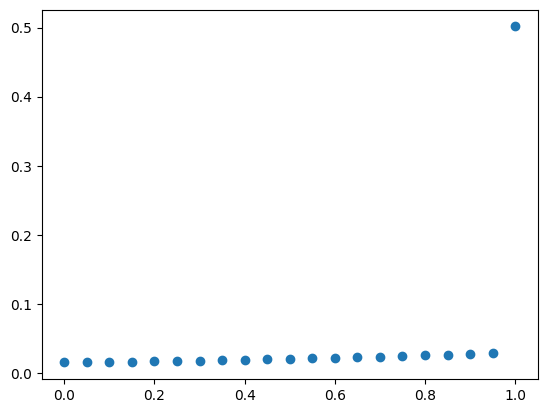

[(np.float64(0.0), np.float64(0.014979189834435639)), (np.float64(0.05), np.float64(0.015381237953296167)), (np.float64(0.1), np.float64(0.015802440555841377)), (np.float64(0.15000000000000002), np.float64(0.016244444063587344)), (np.float64(0.2), np.float64(0.016708888098335456)), (np.float64(0.25), np.float64(0.01719782250467418)), (np.float64(0.30000000000000004), np.float64(0.017713553142530702)), (np.float64(0.35000000000000003), np.float64(0.018258666531254637)), (np.float64(0.4), np.float64(0.01883621219724188)), (np.float64(0.45), np.float64(0.01944981060802306)), (np.float64(0.5), np.float64(0.02010371352092183)), (np.float64(0.55), np.float64(0.020802888422544418)), (np.float64(0.6000000000000001), np.float64(0.021553689155577257)), (np.float64(0.65), np.float64(0.022363504767096493)), (np.float64(0.7000000000000001), np.float64(0.02324211933571088)), (np.float64(0.75), np.float64(0.024201690307350848)), (np.float64(0.8), np.float64(0.025258488925371796)), (np.float64(0.85000

In [26]:
import matplotlib.pyplot as plt

plt.scatter(l_range, ns)
plt.show()
print([(l, n) for l, n in zip(l_range, ns)])